In [ ]:
!pip install torch torchvision timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
!pip install torch torchvision albumentations


In [ ]:
!pip install torch torchvision torchaudio
!pip install -q timm


In [ ]:
import os
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Set permissions
!pip install -q kaggle


In [ ]:
!kaggle datasets download -d karaagroaiprojects/cadi-ai -p /content/Data --unzip


Dataset URL: https://www.kaggle.com/datasets/karaagroaiprojects/cadi-ai
License(s): GNU Affero General Public License 3.0
100% 3.52G/3.52G [01:33<00:00, 42.4MB/s]
100% 3.52G/3.52G [01:33<00:00, 40.3MB/s]


In [ ]:
!ls -R /content/Data | head -n 50


/content/Data:
Data

/content/Data/Data:
test
train
val

/content/Data/Data/test:
test

/content/Data/Data/test/test:
images
labels

/content/Data/Data/test/test/images:
1004.jpg
1026.jpg
1040.jpg
1045.jpg
1048.jpg
1093.jpg
1125.jpg
1133.jpg
1153.jpg
1189.jpg
1206.jpg
1226.jpg
1231.jpg
1306.jpg
1315.jpg
1346.jpg
1347.jpg
1349.jpg
1351.jpg
1354.jpg
1375.jpg
1404.jpg
1416.jpg
1454.jpg
1474.jpg
1475.jpg
1479.jpg
1495.jpg
14.jpg
1506.jpg
1517.jpg
1535.jpg
1541.jpg
1542.jpg


In [ ]:
import os

# Correct dataset paths
dataset_path = "/content/Data/Data"
train_path = os.path.join(dataset_path, "train/train")
val_path = os.path.join(dataset_path, "val/val")
test_path = os.path.join(dataset_path, "test/test")

print("Train Folder Exists:", os.path.exists(train_path))
print("Validation Folder Exists:", os.path.exists(val_path))
print("Test Folder Exists:", os.path.exists(test_path))

# Check number of files in each folder
print("Number of Training Images:", len(os.listdir(os.path.join(train_path, "images"))))
print("Number of Validation Images:", len(os.listdir(os.path.join(val_path, "images"))))
print("Number of Test Images:", len(os.listdir(os.path.join(test_path, "images"))))


Train Folder Exists: True
Validation Folder Exists: True
Test Folder Exists: True
Number of Training Images: 3788
Number of Validation Images: 710
Number of Test Images: 238


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import os


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class CropDiseaseDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # ✅ Filter only image files
        self.image_filenames = sorted([
            f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Load Image
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Load Label
        label_path = os.path.join(self.labels_dir, img_name.replace(".jpg", ".txt"))
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                first_line = f.readline().strip()  # Read only first line

            label = int(first_line.split()[0]) if first_line else -1  # Get class label
        else:
            label = -1  # If label file is missing

        # Apply Transformations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, torch.tensor(label, dtype=torch.long)


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.8, 1.0)),  # Randomly crop and resize
    A.HorizontalFlip(p=0.5),  # Random horizontal flip
    A.RandomBrightnessContrast(p=0.2),  # Adjust brightness & contrast
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),  # Slight shift, scale, rotate
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Slight blur for robustness
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # Standard normalization
    ToTensorV2()
])



In [ ]:
# Define dataset paths
train_images = "/content/Data/Data/train/train/images"
train_labels = "/content/Data/Data/train/train/labels"

val_images = "/content/Data/Data/val/val/images"
val_labels = "/content/Data/Data/val/val/labels"

test_images = "/content/Data/Data/test/test/images"
test_labels = "/content/Data/Data/test/test/labels"

# Create dataset objects
train_dataset = CropDiseaseDataset(train_images, train_labels, transform=transform)
val_dataset = CropDiseaseDataset(val_images, val_labels, transform=transform)
test_dataset = CropDiseaseDataset(test_images, test_labels, transform=transform)

# Define DataLoaders with optimized settings
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=os.cpu_count(), pin_memory=True, drop_last=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                        num_workers=os.cpu_count(), pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=os.cpu_count(), pin_memory=True)


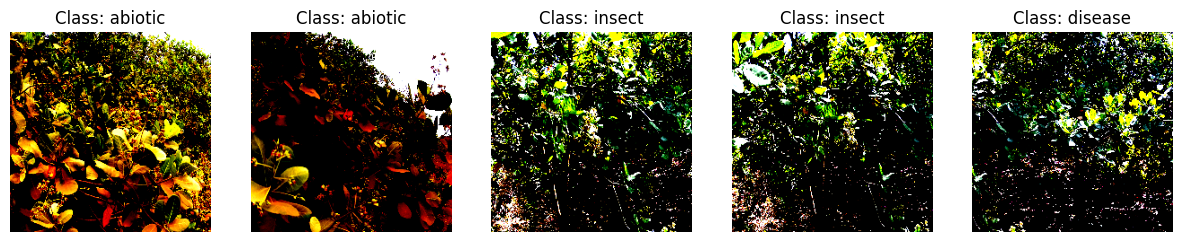

In [ ]:
import matplotlib.pyplot as plt
import torch

# Define class names (based on dataset labels)
class_names = ['abiotic', 'insect', 'disease']

# Function to Unnormalize Image
def unnormalize(image, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(1, 1, 3)
    std = torch.tensor(std).view(1, 1, 3)
    return image * std + mean  # Reverse normalization

# Function to display images
def show_sample_images(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i in range(num_samples):
        image, label = dataset[i]

        # Convert tensor to numpy & Unnormalize
        image = unnormalize(image.permute(1, 2, 0)).cpu().numpy()
        image = (image * 255).astype("uint8")  # Convert to 0-255 range

        # Display Image
        axes[i].imshow(image)
        title = f"Class: {class_names[label]}" if label >= 0 else "Unknown"
        axes[i].set_title(title)
        axes[i].axis("off")

    plt.show()

# ✅ Display samples from the training dataset
show_sample_images(train_dataset)



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


In [ ]:
import os
import shutil

# Define dataset paths
dataset_path = "/content/Data/Data/train/train/images"
label_path = "/content/Data/Data/train/train/labels"
output_path = "/content/Data/Data/train/train_sorted"

# Create class folders if not exist
# Define class names
classes = ['abiotic', 'insect', 'disease']

# ✅ Create class folders if they don't exist
for cls in classes:
    os.makedirs(os.path.join(output_path, cls), exist_ok=True)

# ✅ Move images into respective class folders based on labels
for label_file in os.listdir(label_path):
    if label_file.endswith(".txt"):
        label_file_path = os.path.join(label_path, label_file)

        # Read label file
        with open(label_file_path, "r") as f:
            lines = f.readlines()

        # Skip empty label files
        if not lines:
            continue

        # Extract class label (first value in YOLO format)
        class_idx = int(lines[0].split()[0])  # First value is class index

        if class_idx >= len(classes):
            print(f"⚠️ Warning: Class index {class_idx} out of range in {label_file}")
            continue  # Skip if class index is invalid

        class_name = classes[class_idx]  # Map to class name

        # ✅ Handle multiple image extensions
        possible_extensions = [".jpg", ".jpeg", ".png"]
        img_name = label_file.replace(".txt", "")  # Base name without extension

        # Find correct image file
        for ext in possible_extensions:
            img_path = os.path.join(dataset_path, img_name + ext)
            if os.path.exists(img_path):
                shutil.move(img_path, os.path.join(output_path, class_name, img_name + ext))
                break  # Stop after finding the first matching image

print("✅ Images sorted into class folders successfully!")

✅ Images sorted into class folders successfully!


In [ ]:
train_path = "/content/Data/Data/train/train_sorted"


In [ ]:
import os
import shutil

# Define dataset paths
datasets_paths = {
    "val": "/content/Data/Data/val/val",
    "test": "/content/Data/Data/test/test"
}

output_paths = {
    "val": "/content/Data/Data/val/val_sorted",
    "test": "/content/Data/Data/test/test_sorted"
}

# Define class names
classes = ['abiotic', 'insect', 'disease']

# ✅ Create class folders and move images
for dataset_type, dataset_path in datasets_paths.items():
    output_path = output_paths[dataset_type]
    os.makedirs(output_path, exist_ok=True)

    for cls in classes:
        os.makedirs(os.path.join(output_path, cls), exist_ok=True)

    label_path = os.path.join(dataset_path, "labels")
    image_path = os.path.join(dataset_path, "images")

    # ✅ Check if directories exist
    if not os.path.exists(label_path) or not os.path.exists(image_path):
        print(f"⚠️ Skipping {dataset_type} - Missing directories!")
        continue

    # ✅ Move images based on label files
    for label_file in os.listdir(label_path):
        if label_file.endswith(".txt"):
            label_file_path = os.path.join(label_path, label_file)

            # Read label file
            with open(label_file_path, "r") as f:
                lines = f.readlines()

            # Skip empty label files
            if not lines:
                continue

            # Extract class label
            class_idx = int(lines[0].split()[0])  # First value is class index

            if class_idx >= len(classes):
                print(f"⚠️ Warning: Class index {class_idx} out of range in {label_file}")
                continue  # Skip invalid labels

            class_name = classes[class_idx]  # Map to class name

            # ✅ Handle multiple image extensions
            possible_extensions = [".jpg", ".jpeg", ".png"]
            img_name = label_file.replace(".txt", "")  # Base name without extension

            # Find correct image file
            for ext in possible_extensions:
                img_path = os.path.join(image_path, img_name + ext)
                if os.path.exists(img_path):
                    shutil.move(img_path, os.path.join(output_path, class_name, img_name + ext))
                    break  # Stop after finding the first matching image

print("✅ Validation & Test images sorted into class folders successfully!")


✅ Validation & Test images sorted into class folders successfully!


In [ ]:
# Import necessary libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define dataset paths
train_path = "/content/Data/Data/train/train_sorted"
val_path = "/content/Data/Data/val/val_sorted"
test_path = "/content/Data/Data/test/test_sorted"

# Define image transformations (resize, normalize, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224 for CNN models
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Print dataset sizes
print(f"✅ Training Samples: {len(train_dataset)}")
print(f"✅ Validation Samples: {len(val_dataset)}")
print(f"✅ Test Samples: {len(test_dataset)}")


✅ Training Samples: 2721
✅ Validation Samples: 525
✅ Test Samples: 178


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ------------------------------
# 📌 Swish Activation Function
# ------------------------------
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# ------------------------------
# 📌 Shuffle Block for Channel Mixing
# ------------------------------
class ShuffleBlock(nn.Module):
    def __init__(self, groups=2):
        super(ShuffleBlock, self).__init__()
        self.groups = groups

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        channels_per_group = channels // self.groups
        x = x.view(batch_size, self.groups, channels_per_group, height, width)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        return x.view(batch_size, channels, height, width)

# ------------------------------
# 📌 Ghost Module (Lightweight Feature Extraction)
# ------------------------------
class GhostModule(nn.Module):
    def __init__(self, inp, oup, kernel_size=1, ratio=2, dw_size=3, stride=1):
        super(GhostModule, self).__init__()
        init_channels = oup // ratio
        new_channels = init_channels * (ratio - 1)

        self.primary_conv = nn.Sequential(
            nn.Conv2d(inp, init_channels, kernel_size, stride, kernel_size//2, bias=False),
            nn.BatchNorm2d(init_channels),
            Swish()
        )

        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1, dw_size//2, groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            Swish()
        )

    def forward(self, x):
        primary = self.primary_conv(x)
        cheap = self.cheap_operation(primary)
        return torch.cat([primary, cheap], dim=1)

# ------------------------------
# 📌 Depthwise Separable Convolution (Efficient Convolution)
# ------------------------------
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, kernel_size//2, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.swish = Swish()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.swish(x)

# ------------------------------
# 📌 Squeeze-and-Excitation Block (Adaptive Feature Attention)
# ------------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            Swish(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# ------------------------------
# 📌 FusionNet Architecture (Optimized)
# ------------------------------
class FusionNet(nn.Module):
    def __init__(self, num_classes=3):
        super(FusionNet, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.swish = Swish()

        # Block 1
        self.ghost1 = GhostModule(32, 64)
        self.dwconv1 = DepthwiseSeparableConv(64, 128)
        self.se1 = SEBlock(128)

        # Block 2
        self.shuffle1 = ShuffleBlock()
        self.ghost2 = GhostModule(128, 256)
        self.dwconv2 = DepthwiseSeparableConv(256, 512)
        self.se2 = SEBlock(512)

        # Block 3
        self.shuffle2 = ShuffleBlock()
        self.ghost3 = GhostModule(512, 768)
        self.dwconv3 = DepthwiseSeparableConv(768, 1024)
        self.se3 = SEBlock(1024)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)  # Dropout for regularization
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.swish(self.bn1(self.conv1(x)))

        x = self.ghost1(x)
        x = self.dwconv1(x)
        x = self.se1(x)

        x = self.shuffle1(x)
        x = self.ghost2(x)
        x = self.dwconv2(x)
        x = self.se2(x)

        x = self.shuffle2(x)
        x = self.ghost3(x)
        x = self.dwconv3(x)
        x = self.se3(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)  # Apply dropout before FC layer
        return self.fc(x)

# ------------------------------
# ✅ Model Initialization & Summary
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FusionNet(num_classes=3).to(device)

print(model)


FusionNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (ghost1): GhostModule(
    (primary_conv): Sequential(
      (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (cheap_operation): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (dwconv1): DepthwiseSeparableConv(
    (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
    (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05,

In [ ]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using Device:", device)

# Move model to the selected device
model.to(device)


✅ Using Device: cuda


FusionNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (ghost1): GhostModule(
    (primary_conv): Sequential(
      (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (cheap_operation): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (dwconv1): DepthwiseSeparableConv(
    (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
    (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05,

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# 🔹 Auto-Select Num Workers Based on CPU Cores
num_workers = min(4, torch.get_num_threads())

# 🔹 Define Advanced Data Augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.RandomHorizontalFlip(),  # Random Flip
    transforms.RandomRotation(10),  # Random Rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color Variation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random Translation
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Perspective Distortion
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),  # Simulate Occlusion
    transforms.ToTensor(),  # Convert to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 🔹 Load Dataset
train_dataset = datasets.ImageFolder(root="/content/Data/Data/train/train_sorted", transform=train_transform)
val_dataset = datasets.ImageFolder(root="/content/Data/Data/val/val_sorted", transform=val_transform)
test_dataset = datasets.ImageFolder(root="/content/Data/Data/test/test_sorted", transform=val_transform)

# 🔹 Adaptive Batch Size (If GPU RAM is Limited)
default_batch_size = 32
batch_size = default_batch_size if torch.cuda.is_available() else 16

# 🔹 Create Dataloaders with Optimized Performance
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True, persistent_workers=True
)

# 🔹 Print Dataset Sizes
print(f"✅ Training Samples: {len(train_dataset)}")
print(f"✅ Validation Samples: {len(val_dataset)}")
print(f"✅ Test Samples: {len(test_dataset)}")
print(f"🔹 Batch Size: {batch_size} | Num Workers: {num_workers}")


✅ Training Samples: 2721
✅ Validation Samples: 525
✅ Test Samples: 178


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

# 🔹 Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FusionNet().to(device)

# 🔹 Define Loss, Optimizer, and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)  # AdamW for stability
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 🔹 Initialize GradScaler for mixed precision training
scaler = GradScaler()

# 🔹 Training Function with Mixed Precision & Gradient Clipping
def train_model(model, train_loader, criterion, optimizer, device, scaler, clip_value=1.0):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # 🔸 Enable Mixed Precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # 🔹 Scale loss and perform backward pass
        scaler.scale(loss).backward()

        # 🔹 Gradient Clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

        # 🔹 Step Optimizer
        scaler.step(optimizer)
        scaler.update()

        # 🔹 Convert FP16 loss to FP32 and accumulate
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # 🔹 Clean up memory
        del loss
        torch.cuda.empty_cache()

    train_loss = total_loss / len(train_loader)
    train_accuracy = correct / total * 100
    return train_loss, train_accuracy

# 🔹 Validation Function with FP16 + Efficient Evaluation
def validate_model(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    # 🔸 Use `torch.inference_mode()` for efficient inference
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():  # Mixed Precision
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = correct / total * 100

    # 🔹 Step LR Scheduler (Reduce LR on Plateau)
    scheduler.step(val_loss)

    return val_loss, val_accuracy


<ipython-input-21-ae9afcc6dbd7>:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
import time
import torch

# 🔹 Set number of epochs & early stopping parameters
num_epochs = 35
best_val_loss = float("inf")
patience = 5  # Stop training if no improvement for `patience` epochs
no_improve_epochs = 0

# 🔹 Training Loop
for epoch in range(num_epochs):
    start_time = time.perf_counter()

    # 🔹 Train & Validate
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate_model(model, val_loader, criterion, device)

    # 🔹 Update LR Scheduler (ReduceLROnPlateau)
    scheduler.step(val_loss)

    # 🔹 Track Best Model & Save Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_epochs = 0  # Reset counter
        torch.save(model.state_dict(), "best_fusionnet.pth")  # Save best model
        print("✅ Model improved & saved!")
    else:
        no_improve_epochs += 1  # Increase counter

    # 🔹 Check Early Stopping
    if no_improve_epochs >= patience:
        print(f"⏹ Early stopping triggered! No improvement for {patience} epochs.")
        break

    # 🔹 End Time Calculation
    end_time = time.perf_counter()
    epoch_time = end_time - start_time

    # 🔹 Print Metrics with Learning Rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📢 Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% - "
          f"LR: {current_lr:.6f} - Time: {epoch_time:.2f}s")



<ipython-input-21-ae9afcc6dbd7>:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
<ipython-input-21-ae9afcc6dbd7>:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed Precision


Epoch [1/35] - Train Loss: 0.9844, Train Acc: 53.29% - Val Loss: 1.0474, Val Acc: 53.71% - Time: 176.29s
Epoch [2/35] - Train Loss: 0.9450, Train Acc: 55.71% - Val Loss: 0.9609, Val Acc: 57.14% - Time: 173.39s
Epoch [3/35] - Train Loss: 0.9139, Train Acc: 56.56% - Val Loss: 0.9700, Val Acc: 56.38% - Time: 172.85s
Epoch [4/35] - Train Loss: 0.8934, Train Acc: 58.47% - Val Loss: 0.9574, Val Acc: 63.24% - Time: 173.43s
Epoch [5/35] - Train Loss: 0.8817, Train Acc: 58.07% - Val Loss: 0.8196, Val Acc: 65.33% - Time: 176.97s
Epoch [6/35] - Train Loss: 0.8529, Train Acc: 61.23% - Val Loss: 0.8126, Val Acc: 64.38% - Time: 173.64s
Epoch [7/35] - Train Loss: 0.8358, Train Acc: 61.74% - Val Loss: 0.8081, Val Acc: 64.00% - Time: 175.26s
Epoch [8/35] - Train Loss: 0.8444, Train Acc: 61.08% - Val Loss: 0.7941, Val Acc: 68.19% - Time: 176.10s
Epoch [9/35] - Train Loss: 0.8391, Train Acc: 62.18% - Val Loss: 0.8112, Val Acc: 66.86% - Time: 175.16s
Epoch [10/35] - Train Loss: 0.8368, Train Acc: 62.99% -

In [ ]:
test_loss, test_acc = validate_model(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")


NameError: name 'validate_model' is not defined